In [11]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import sqlite3

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Configuracion de visualizacion
%matplotlib inline
sns.set_theme(style="whitegrid")

In [12]:
#Bloque 1: Generacion de Datos y Logica de Negocio

In [13]:
# Generacion de Dataset Sucio
np.random.seed(42)
n=10000

df_seguros = pd.DataFrame({
    "id_poliza": range(1000, 1000+n),
    "fecha_inicio_poliza": [datetime.date(2025, 1, 1) + datetime.timedelta(days=np.random.randint(0, 365)) for _ in range(n)],
    "fecha_siniestro": [datetime.date(2025, 1, 1) + datetime.timedelta(days=np.random.randint(0, 365)) for _ in range(n)],
    "monto_reclamo": np.random.normal(500000, 200000, n),
    "valor_vehiculo": np.random.uniform(5000000, 15000000, n),
    "zona_siniestro": np.random.choice(["CABA", "GBA_Norte", "GBA_Sur", "GBA_Oeste", "CABA"], n, p=[0.3, 0.2, 0.2, 0.2, 0.1]),
    "tipo_siniestro": np.random.choice(["Choque", "Robo_Parcial", "Cristales", "Incendio"], n),
    "historial_siniestros": np.random.poisson(0.5, n) #cuantos choques tuvo antes
})

# Paso las columnas a formato fecha de Pandas para que funcione el .dt
df_seguros['fecha_inicio_poliza'] = pd.to_datetime(df_seguros['fecha_inicio_poliza'])
df_seguros['fecha_siniestro'] = pd.to_datetime(df_seguros['fecha_siniestro'])

# Target de Fraude basado en Logica (lo que el modelo debe descubrir)
df_seguros['es_fraude'] = 0

# Regla de fraude: Choque en GBA_Sur + menos de 15 dias de poliza
mask_fraude = (df_seguros['zona_siniestro'] == "GBA_Sur") & \
              ((df_seguros['fecha_siniestro'] - df_seguros['fecha_inicio_poliza']).dt.days < 15) & \
              ((df_seguros['fecha_siniestro'] - df_seguros['fecha_inicio_poliza']).dt.days >= 0)

df_seguros.loc[mask_fraude, 'es_fraude'] = 1

print("Dataset cargado. Filas con nulos:\n", df_seguros.isnull().sum())
print(f"\nTotal de fraudes detectados: {df_seguros['es_fraude'].sum()}")

Dataset cargado. Filas con nulos:
 id_poliza               0
fecha_inicio_poliza     0
fecha_siniestro         0
monto_reclamo           0
valor_vehiculo          0
zona_siniestro          0
tipo_siniestro          0
historial_siniestros    0
es_fraude               0
dtype: int64

Total de fraudes detectados: 80


In [14]:
#Bloque 2: Visualizacion de Siniestralidad

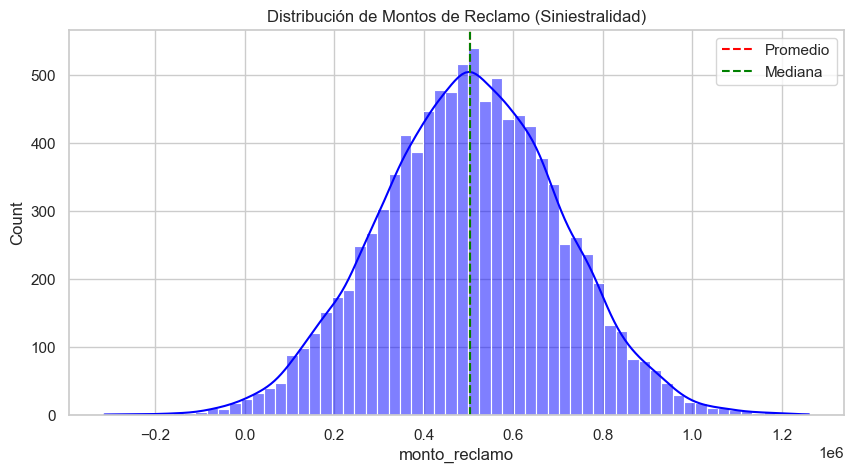

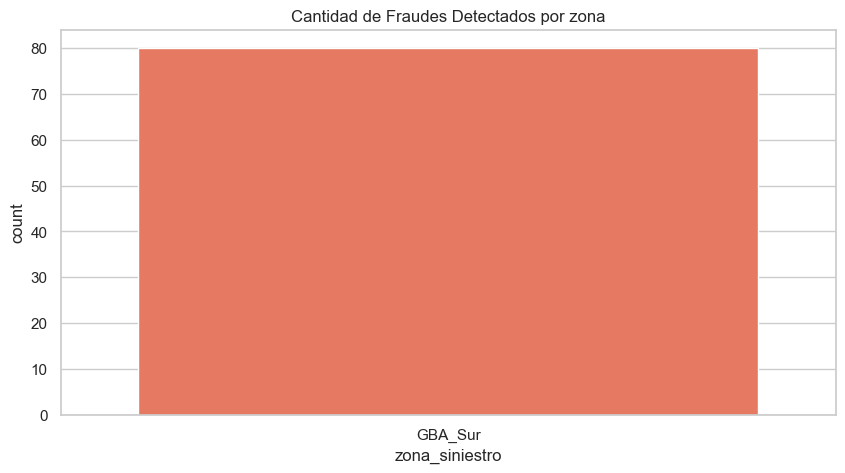

In [15]:
# ¿Como se distribuyen los montos de los reclamos?
plt.figure(figsize=(10, 5))
sns.histplot(df_seguros['monto_reclamo'], kde=True, color='blue')
plt.axvline(df_seguros['monto_reclamo'].mean(), color='red', linestyle='--', label='Promedio')
plt.axvline(df_seguros['monto_reclamo'].median(), color='green', linestyle='--', label='Mediana')
plt.title('Distribución de Montos de Reclamo (Siniestralidad)')
plt.legend()
plt.show()

# Fraude por Zona 
plt.figure(figsize=(10, 5))
sns.countplot(data=df_seguros[df_seguros['es_fraude'] == 1], 
              x='zona_siniestro', 
              hue='zona_siniestro', 
              palette='Reds_r', 
              legend=False)
plt.title('Cantidad de Fraudes Detectados por zona')
plt.show()

In [16]:
#Se observa una alta concentración de siniestros sospechosos en GBA_Sur.
#Aunque la severidad (montos) es normal, la frecuencia en esta zona indica un patrón de fraude organizado relacionado con la contratación reciente

In [17]:
#Bloque 3: Loss Ratio

In [18]:
# Defino la Prima Promedio (lo que cada cliente paga por su seguro)
#En Argentina, una prima anual promedio para este tipo de vehiculos
prima_promedio = 600000

# Agrupo por zona para calcular totales
reporte_siniestralidad = df_seguros.groupby('zona_siniestro').agg(
    total_siniestros = ('monto_reclamo', 'sum'),
    cantidad_polizas = ('id_poliza', 'count')
).reset_index()

# Calculo de Ingreso Total y el Loss Ratio
reporte_siniestralidad['ingresos_primas'] = reporte_siniestralidad['cantidad_polizas'] * prima_promedio
reporte_siniestralidad['loss_ratio'] = reporte_siniestralidad['total_siniestros'] / reporte_siniestralidad['ingresos_primas']

# Formato
reporte_siniestralidad['loss_ratio_pct'] = (reporte_siniestralidad['loss_ratio'] * 100).round(2)
print(reporte_siniestralidad[['zona_siniestro', 'loss_ratio_pct']].sort_values(by='loss_ratio_pct', ascending=False))

  zona_siniestro  loss_ratio_pct
2      GBA_Oeste           84.88
1      GBA_Norte           83.88
3        GBA_Sur           83.59
0           CABA           83.45


In [19]:
#Loss Ratio del 84%: Cada $100 que entran por primas, $84 se van directo a pagar choques. La ganancia, despues de otros gastos, es baja.

In [20]:
#Bloque 4: Machine Learnin 
#Deteccion mas fina para identificar patrones

In [21]:
# Preparacion de las variables (Features) y lo que queremos predecir (Target)
# Selecciono variables numericas que ayuden a predecir
X = df_seguros[['monto_reclamo', 'valor_vehiculo', 'historial_siniestros']]

# Agrego la zona convirtiendola en numeros (One Hot Encoding)
X = pd.concat([X, pd.get_dummies(df_seguros['zona_siniestro'])], axis=1)

y = df_seguros['es_fraude']

# Divido los datos: una parte para entrenar y otra para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entreno el modelo (Random Forest)
modelo_fraude = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_fraude.fit(X_train, y_train)

# Evaluo el resultado
print("Examen del modelo completado.")
print(classification_report(y_test, modelo_fraude.predict(X_test)))

Examen del modelo completado.
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1983
           1       0.00      0.00      0.00        17

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.98      0.99      0.99      2000



In [22]:
#Bloque 5: La Transicion a SQL
#Voy a separar el df_seguros en 2 tablas

In [23]:
#Creo la Tabla de Clientes
df_clientes = df_seguros[['id_poliza', 'zona_siniestro', 'historial_siniestros']].copy()
df_clientes.columns = ['id_cliente', 'zona', ' scoring_previo']

#Creo la Tabla de siniestros
df_hechos_siniestros = df_seguros[['id_poliza', 'fecha_siniestro', 'monto_reclamo', 'tipo_siniestro', 'es_fraude']].copy()
print("Tablas relacionales creadas. Listas para el analisis SQL.")

Tablas relacionales creadas. Listas para el analisis SQL.


In [24]:
# Crea una base de datos temporal en memoria
conn = sqlite3.connect(':memory:')
df_clientes.to_sql('clientes', conn, index=False)
df_hechos_siniestros.to_sql('siniestros', conn, index=False)

# Query
query = """
SELECT 
    c.zona,
    SUM(s.monto_reclamo) as costo_total,
    COUNT(s.id_poliza) as cantidad_casos
FROM clientes c
JOIN siniestros s ON c.id_cliente = s.id_poliza
WHERE s.es_fraude = 1
GROUP BY c.zona
ORDER BY costo_total DESC
"""

df_resultado_sql = pd.read_sql_query(query, conn)
print(df_resultado_sql)

      zona   costo_total  cantidad_casos
0  GBA_Sur  4.126053e+07              80


In [25]:
#Bloque 6: Preparacion del Dashboard (POWER BI)

In [26]:
# Guardo el dataset final limpio para Power BI
df_seguros.to_csv('Data_Seguros_Final.csv', index=False)

# Exporto la tabla de resultados de SQL por zona
df_resultado_sql.to_csv('Resumen_Fraude_Zona.csv', index=False)

print("Archivos listos para abrir en Power BI!")

Archivos listos para abrir en Power BI!
